<a href="https://colab.research.google.com/github/Rmendivil94/retail-fraud-detection/blob/main/notebooks/03_Model_Training_and_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**IEEE-CIS Fraud Detection: Train and Validation (Out-of-Time)**

##I. Loading data | Cargando la data

In [2]:
import pandas as pd
import numpy as np
from google.colab import drive

# 1. Set up the 'Data Lake' | Montar el "Data Lake"
drive.mount('/content/drive')

# 2. Automated extraction of the train data | Ingesta automatizada de la data de entrenamiento
intake_path = '/content/drive/MyDrive/Portfolio_Fraud_Detection/data/train_final_features.parquet'
print(f"Starting data intake from: {intake_path}")
df = pd.read_parquet(intake_path)

Mounted at /content/drive
Starting data intake from: /content/drive/MyDrive/Portfolio_Fraud_Detection/data/train_final_features.parquet


##II. Split the data cronologically in train and test | Dividir la data cronológicamente en train y test

In [3]:
# 1. Sorting cronologically | Ordenar cronológicamente
df = df.sort_values('TransactionDT').reset_index(drop = True)

# 2. Calculate the cutoff index for 80/20 | Calcular el índice de corte para el 80/20
split_index = int(len(df) * 0.80)

# 3. Split by index | Hacer el corte por índice
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

print(f"Train (Past): {len(train_df)} rows")
print(f"Test (Future): {len(test_df)} rows")

# 4. Separate the predictor variables (X) from the target variable (y) | Separar las variables predictoras (X) de la variable objetivo (y)
  # Columns to drop
cols_to_drop = ['TransactionID', 'isFraud', 'TransactionDT']

X_train = train_df.drop(columns = [col for col in cols_to_drop if col in train_df.columns])
y_train = train_df['isFraud']

X_test = test_df.drop(columns = [col for col in cols_to_drop if col in test_df.columns])
y_test = test_df['isFraud']

print(f"\nNumber of features to train the model: {X_train.shape[1]}")

Train (Past): 472432 rows
Test (Future): 118108 rows

Number of features to train the model: 67


##III. Set and Train the XGBoost model | Configurar y Entrenar el modelo XGBoost

###III.a) Training the model 1 | Entrenando el modelo 1

In [4]:
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

print("Setting XGBoost Model...")

# 1. Calculate the class imbalance weight | Calcular el peso para el desbalanceo de clases
# weight = (Total negatives / Total positives) | peso = (Total Negativos / Total Positivos)
class_weight = (y_train == 0).sum() / (y_train == 1).sum()

# 2. Define the model's hiperparameters | Definir los hiperparámetros del modelo
# Conservative parameters to avoid overfitting on the first attempt | Parámetros conservadores para evitar overfitting en el primer intento
xgb_model = xgb.XGBClassifier(
    n_estimators = 300,            # # of trees
    max_depth = 5,                 # Max. depth
    learning_rate = 0.05,          # Learning rate
    scale_pos_weight = class_weight,# Weight
    subsample = 0.8,               # Use 80% of rows per tree (avoids overfitting)
    colsample_bytree = 0.8,        # Use 80% of columns per tree
    eval_metric = 'auc',           # Evaluation metric
    random_state = 42,
    n_jobs = -1
)

# 3. Train the model with Early Stopping | Entrenar el modelo con Early Stopping
# XGBoost stops after 30 rounds with no better results | XGBoost se detiene si no mejora en el set de prueba después de 30 rondas
print("Starting training...")
eval_set = [(X_train, y_train), (X_test, y_test)]

xgb_model.fit(
    X_train, y_train,
    eval_set = eval_set,
    verbose = 50 # Print progress every 50 trees
)

# 4. Predictions | Predicciones
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
y_pred = xgb_model.predict(X_test)

# 5. ROC-AUC
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"FINAL ROC-AUC SCORE: {auc_score:.4f}")

Setting XGBoost Model...
Starting training...
[0]	validation_0-auc:0.83619	validation_1-auc:0.82885
[50]	validation_0-auc:0.89073	validation_1-auc:0.87007
[100]	validation_0-auc:0.90783	validation_1-auc:0.88395
[150]	validation_0-auc:0.91796	validation_1-auc:0.89164
[200]	validation_0-auc:0.92652	validation_1-auc:0.89629
[250]	validation_0-auc:0.93252	validation_1-auc:0.90009
[299]	validation_0-auc:0.93844	validation_1-auc:0.90269
FINAL ROC-AUC SCORE: 0.9027


###III.b) Confusion Matrix | Matriz de Confusión

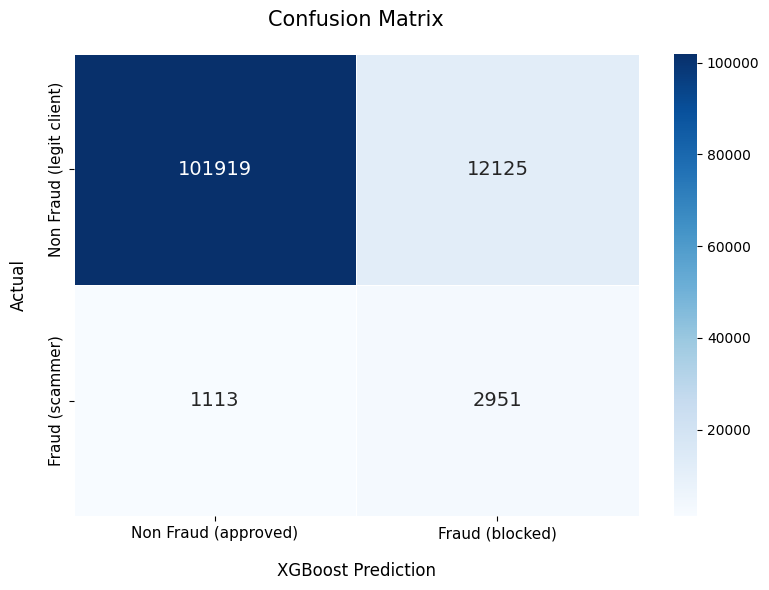

               precision    recall  f1-score   support

Non-fraud (0)       0.99      0.89      0.94    114044
    Fraud (1)       0.20      0.73      0.31      4064

     accuracy                           0.89    118108
    macro avg       0.59      0.81      0.62    118108
 weighted avg       0.96      0.89      0.92    118108



In [5]:
import numpy as np

# 1. Confusion Matrix | Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)

# 2. Visualization | Visualización
plt.figure(figsize = (8 , 6))
# Heatmap | Mapa de calor
ax = sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', linewidths = 0.5, annot_kws = {"size": 14})

# 3. Business labels | Etiquetas de negocio
ax.set_title('Confusion Matrix', fontsize = 15, pad = 20)
ax.set_xlabel('XGBoost Prediction', fontsize = 12, labelpad = 15)
ax.set_ylabel('Actual', fontsize = 12, labelpad = 15)
ax.xaxis.set_ticklabels(['Non Fraud (approved)', 'Fraud (blocked)'], fontsize = 11)
ax.yaxis.set_ticklabels(['Non Fraud (legit client)', 'Fraud (scammer)'], fontsize = 11)

plt.tight_layout()
plt.show()

# 4. Classification Report | Reporte de Clasificación (Precision, Recall, F1)
print(classification_report(y_test, y_pred, target_names=['Non-fraud (0)', 'Fraud (1)']))

>EN: By observing the confusion matrix, we note that the current model detects 73% of actual fraud, generating a projected savings of over $220,000 USD by mitigating total losses and chargebacks. However, the volume of False Positives (12,125 legitimate transactions blocked) represents severe friction for the customer and an opportunity cost in lost profits. Although the net ROI of the model is positive, it is imperative to calibrate the sensitivity of the algorithm to reduce the false positive rate and protect the user experience before production deployment.


---


>ES: Al observar la matriz de confusión, notamos que el modelo actual detecta el 73% del fraude real, generando un ahorro proyectado superior a los $220,000 USD al mitigar pérdidas totales y contracargos. Sin embargo, el volumen de Falsos Positivos (12,125 transacciones legítimas bloqueadas) representa una fricción severa para el cliente y un costo de oportunidad en lucro cesante. Aunque el ROI neto del modelo es positivo, es imperativo calibrar la sensibilidad del algoritmo para reducir la tasa de falsos positivos y proteger la experiencia de usuario antes de un despliegue en producción.

###III.c) Adjusting sensibility to maximize F1-score | Ajustando la sensibilidad para maximizar F1-Score

> EN: Instead of using an empirical decision threshold (such as the conventional 0.80), we will use a data-driven approach. We will calculate the optimal mathematical threshold by maximizing the F1-Score, allowing us to find the exact balance between Precision (minimizing the blocking of legitimate transactions) and Recall (maximizing the interception of fraudsters). This optimization ensures that the model's predictions are perfectly aligned with the actual financial profitability of the business.


---
> ES: En vez de usar umbral de decisión empírico (como el convencional 0.80), usaremos un enfoque basado en datos. Calcularemos el umbral matemático óptimo maximizando el F1-Score, lo que nos permite encontrar el punto de equilibrio exacto entre Precision (minimizar el bloqueo de transacciones legítimas) y el Recall (maximizar la intercepción de estafadores). Esta optimización garantiza que las predicciones del modelo estén alineadas con la rentabilidad real del negocio.



In [6]:
from sklearn.metrics import precision_recall_curve

# 1. Getting the metrics and all the possible umbrals | Obtener las métricas y todos los umbrales posibles
precisions, recalls, thresholds = precision_recall_curve(y_test , y_pred_proba)

# 2. Calculate F1-Score for each threshold | Calcular el F1-Score para cada umbral
# Formula: F1 = 2 * (Precision * Recall) / (Precision + Recall)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10) #Adding 1e-10 to avoid division by 0

# 3. Finding the index where F1-Score is max | Encontrar el índice donde el F1-Score es máximo
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"\nOptimal Threshold: {optimal_threshold:.4f}")


Optimal Threshold: 0.8272


###III.d) New Confusion Matrix | Nueva Matriz de Confusión

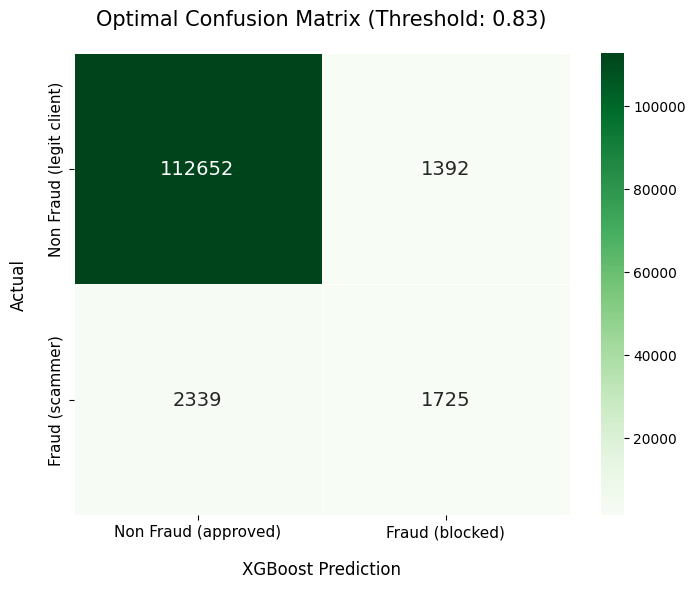

               precision    recall  f1-score   support

Non-fraud (0)       0.98      0.99      0.98    114044
    Fraud (1)       0.55      0.42      0.48      4064

     accuracy                           0.97    118108
    macro avg       0.77      0.71      0.73    118108
 weighted avg       0.96      0.97      0.97    118108



In [7]:
# 1. Apply the new threshold to the predictions | Aplicar el nuevo umbral a las predicciones
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)

# 2. Calculate the new confusion matrix | Calcular la nueva matriz de confusión
cm_optimal = confusion_matrix(y_test, y_pred_optimal)

plt.figure(figsize = (8 , 6))
ax = sns.heatmap(cm_optimal, annot = True, fmt = 'd', cmap = 'Greens', linewidths = 0.5, annot_kws = {"size": 14})
ax.set_title(f'Optimal Confusion Matrix (Threshold: {optimal_threshold:.2f})', fontsize = 15, pad = 20)
ax.set_xlabel('XGBoost Prediction', fontsize = 12, labelpad = 15)
ax.set_ylabel('Actual', fontsize = 12, labelpad = 15)
ax.xaxis.set_ticklabels(['Non Fraud (approved)', 'Fraud (blocked)'], fontsize = 11)
ax.yaxis.set_ticklabels(['Non Fraud (legit client)', 'Fraud (scammer)'], fontsize = 11)
plt.show()

# 3. New classification report | Nuevo reporte de clasificación
print(classification_report(y_test, y_pred_optimal, target_names=['Non-fraud (0)', 'Fraud (1)']))

###III.e) Adjusting sensibility to maximum financial profitability  | Ajustando la sensibilidad para máxima rentabilidad financiera

>EN: In retail fraud detection, prediction errors have asymmetric financial costs. We transition from traditional academic metrics (like F1-Score) to an Expected Value framework.
* A False Positive (blocking a legitimate customer) costs the business its profit margin (opportunity cost, approx. 10% of the value of the legitimate transaction, whose median is ``$68.5``) estimated at ``$6.85``.
* A False Negative (missing an actual fraudster) results in a total loss of the physical product plus bank chargeback fees (>100% of the transaction value, estimated at ``$75.00``).
Instead of using a default 0.50 cutoff, we compute a Profit Curve across all possible probability thresholds to pinpoint the exact decision boundary that maximizes net revenue for the company.


---

>ES: En la detección de fraude en retail, los errores de predicción tienen costos financieros asimétricos. Dejamos atrás las métricas académicas tradicionales (como el F1-Score) y maximizamos el Valor Esperado.
* Un Falso Positivo (bloquear una transacción legítima) le cuesta al negocio su margen de ganancia (aprox. 10% del valor de la transacción legítima, cuya mediana es `$68.5`), estimado en `$6.85`.
* Un Falso Negativo (no detectar a un estafador) resulta en la pérdida total del producto físico más las multas de contracargo bancario (>100% del valor de la transacción fraudulenta, estimado en `$75.00`).
En lugar de utilizar un corte predeterminado de 0.50, calculamos una Curva de Rentabilidad a través de todos los umbrales de probabilidad posibles para identificar el límite de decisión exacto que maximiza los ingresos netos para la compañía.


Financial threshold: 0.5859
Max. Profit: $146,398.65 USD


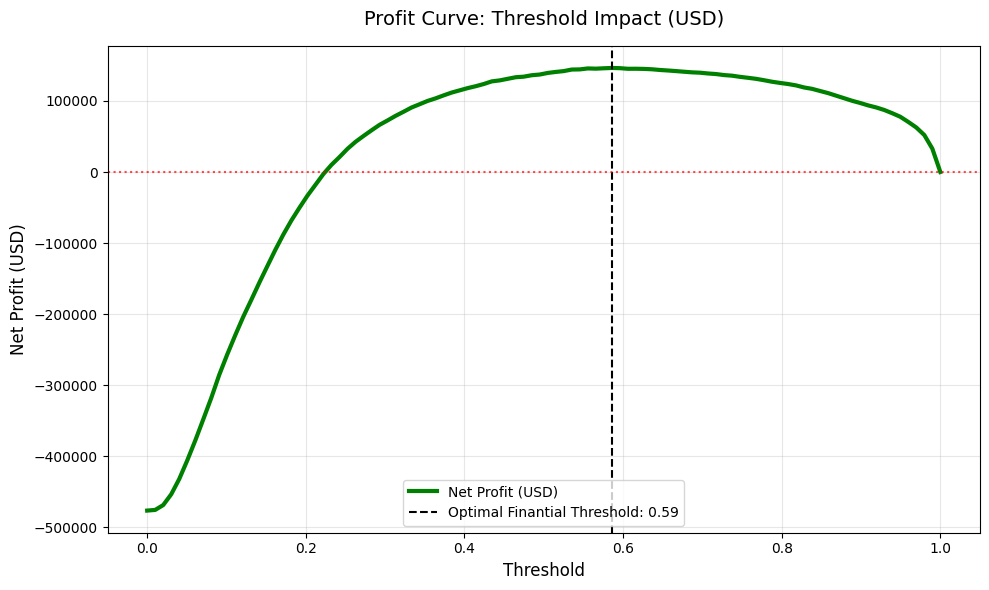

In [10]:
# 1. Business real costs | Costos reales del negocio
saves_avoid_fraud = 75  # Dollars saved (True Positive)
cost_false_positive= 6.85   # Dollars lost in margin (False Positive)

thresholds_ = np.linspace(0.0, 1.0, 100)
profits = []

# 2. Financial Impact for each threshold | Impacto financiero para cada umbral
for threshold in thresholds_:
    # Prediction for each threshold | Predicciones para cada umbral
    y_pred_temp = (y_pred_proba >= threshold).astype(int)
    cm_temp = confusion_matrix(y_test, y_pred_temp)

    # Extracting TP and FP | Extraer TP y FP
    if cm_temp.shape == (2, 2): # ensuring that the matrix is 2x2
        tp = cm_temp[1, 1]
        fp = cm_temp[0, 1]
    else:
        tp = 0
        fp = 0

    # Net profit formula | Fórmula de ganancia neta
    net_profit = (tp * saves_avoid_fraud) - (fp * cost_false_positive)
    profits.append(net_profit)

# 3. Threshold that generates the highest profit  | Umbral que genera la mayor rentabilidad
optm_index = np.argmax(profits)
financial_threshold = thresholds_[optm_index]
max_profit = profits[optm_index]

print(f"\nFinancial threshold: {financial_threshold:.4f}")
print(f"Max. Profit: ${max_profit:,.2f} USD")

# 4. Profit Curve | Curva de Rentabilidad
plt.figure(figsize = (10 , 6))
plt.plot(thresholds_, profits, color = 'green', linestyle = '-', linewidth = 3,
         label = 'Net Profit (USD)')
plt.axvline(x = financial_threshold, color = 'black', linestyle = '--',
            label = f'Optimal Finantial Threshold: {financial_threshold:.2f}')
plt.axhline(y = 0, color = 'red', linestyle = ':', alpha = 0.7) # Lost reference

plt.title('Profit Curve: Threshold Impact (USD)', fontsize = 14, pad = 15)
plt.xlabel('Threshold', fontsize = 12)
plt.ylabel('Net Profit (USD)', fontsize = 12)
plt.legend(loc = 'lower center')
plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

###III.f) Final Confusion Matrix | Matriz de Confusión Final

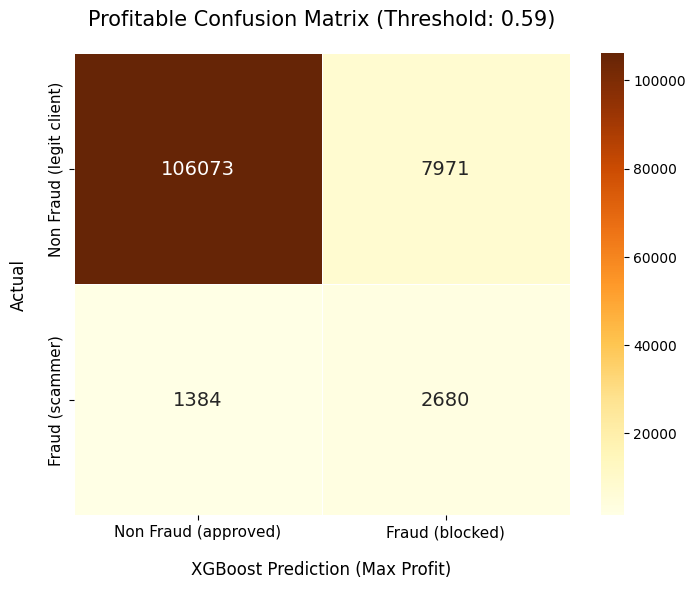

In [11]:
# 1. Apply the new threshold to the predictions | Aplicar el nuevo umbral a las predicciones
y_pred_final = (y_pred_proba >= financial_threshold).astype(int)
cm_final = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize = (8, 6))
# 2. Calculate the new confusion matrix | Calcular la nueva matriz de confusión
ax = sns.heatmap(cm_final, annot = True, fmt = 'd', cmap = 'YlOrBr', linewidths = 0.5, annot_kws = {"size": 14})
ax.set_title(f'Profitable Confusion Matrix (Threshold: {financial_threshold:.2f})', fontsize = 15, pad = 20)
ax.set_xlabel('XGBoost Prediction (Max Profit)', fontsize = 12, labelpad = 15)
ax.set_ylabel('Actual', fontsize = 12, labelpad = 15)
ax.xaxis.set_ticklabels(['Non Fraud (approved)', 'Fraud (blocked)'], fontsize = 11)
ax.yaxis.set_ticklabels(['Non Fraud (legit client)', 'Fraud (scammer)'], fontsize = 11)
plt.show()

>EN: The profit curve revealed the optimal decision threshold to be 0.5859. By deploying this specific predictive threshold, the model stabilizes its fraud detection rate at 66% while minimizing customer friction (blocking of legitimate transactions), yielding a net savings of ``$149,188.50`` on the test set.


---

>ES: La curva de rentabilidad determinó que el umbral de decisión óptimo es 0.5859. Al aplicar este umbral predictivo, el modelo estabiliza su tasa de detección de fraude en un 66% mientras minimiza la fricción del cliente (bloqueo de transacciones legítimas), proyectando un ahorro neto de ``$149,188.50`` sobre el conjunto de prueba.

##IV. Deploying the model | Despliegue del modelo

In [12]:
import joblib
import os

# 1. Create the models folder in our Data Lake (Drive) | Crear la carpeta de modelos en nuestro Data Lake (Drive)
models_path = '/content/drive/MyDrive/Portfolio_Fraud_Detection/models'
os.makedirs(models_path, exist_ok = True)

# 2. ARTIFACT 1: THE MODEL | ARTEFACTO 1: EL MODELO (JSON FORMAT)
xgb_path = f'{models_path}/xgboost_fraud_model.json'
# Native method | Método nativo
xgb_model.save_model(xgb_path)
print(f"XGBoost model exported to: {xgb_path}")

# 3. ARTIFACT 2: PRODUCTION METADATA | ARTEFACTO 2: METADATA DE PRODUCCIÓN (Joblib)
# Financial threshold and train features
production_metadata = {
    'optimal_financial_threshold': financial_threshold,
    'train_features': list(X_train.columns)
}

metadata_path = f'{models_path}/production_metadata.joblib'
joblib.dump(production_metadata, metadata_path)
print(f"Metadata (Threshold and Features) esported to: {metadata_path}")

print("ALL ARTIFACTS EXPORTED TO PRODUCTION")

XGBoost model exported to: /content/drive/MyDrive/Portfolio_Fraud_Detection/models/xgboost_fraud_model.json
Metadata (Threshold and Features) esported to: /content/drive/MyDrive/Portfolio_Fraud_Detection/models/production_metadata.joblib
ALL ARTIFACTS EXPORTED TO PRODUCTION
